In [ ]:
# 🏥 Healthcare Capstone: Breast Cancer Tumor Classification

## Project Components
| Requirement        | Implementation                              |
|--------------------|---------------------------------------------|
| Data Processing    | Cells 1-5: Cleansing + 3 Visualizations     |
| Machine Learning   | Cells 6-8: Random Forest Classifier         |
| Generative AI      | Cell 9: Gemini API — Clinical Summary Gen.  |

Dataset: Wisconsin Breast Cancer Dataset (sklearn built-in)
Goal: Classify tumors as malignant/benign + communicate results via AI

In [ ]:
!pip install -q google-genai

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['diagnosis'] = pd.Categorical.from_codes(cancer.target, ['malignant', 'benign'])

print("Dataset Shape:", df.shape)
print("\nDiagnosis Counts:")
print(df['diagnosis'].value_counts())
df.head()

Dataset Shape: (569, 31)

Diagnosis Counts:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [ ]:
print("=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values found")

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Missing Values ===
0 missing values found

=== Basic Statistics ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


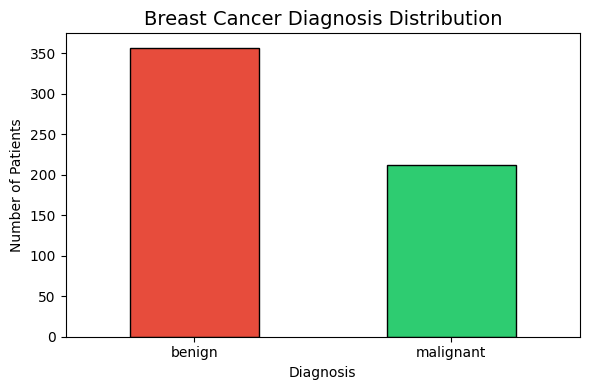

Chart saved!


In [ ]:
plt.figure(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Breast Cancer Diagnosis Distribution', fontsize=14)
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('diagnosis_distribution.png')
plt.show()
print("Chart saved!")

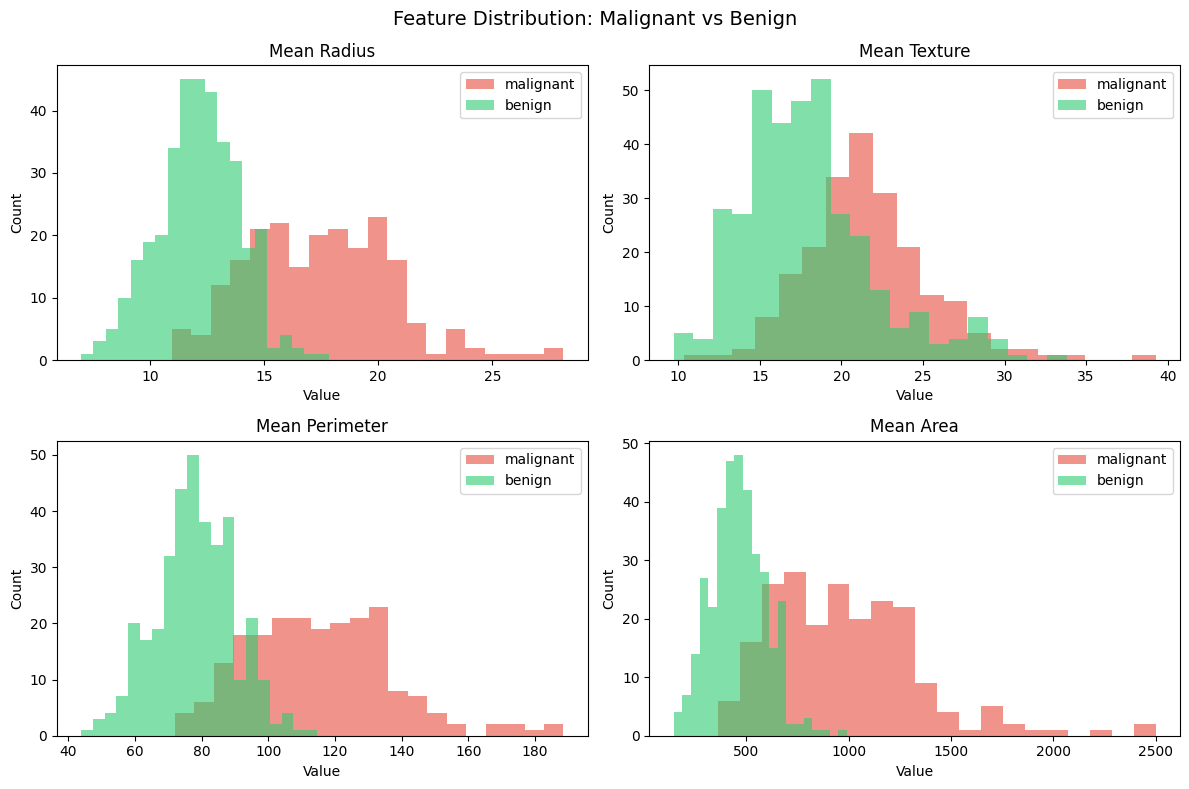

Chart saved!


In [ ]:
# Compare top 4 features between malignant and benign
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for diagnosis, color in zip(['malignant', 'benign'], ['#e74c3c', '#2ecc71']):
        subset = df[df['diagnosis'] == diagnosis][feature]
        axes[i].hist(subset, alpha=0.6, label=diagnosis, color=color, bins=20)
    axes[i].set_title(f'{feature.title()}')
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distribution: Malignant vs Benign', fontsize=14)
plt.tight_layout()
plt.savefig('feature_comparison.png')
plt.show()
print("Chart saved!")

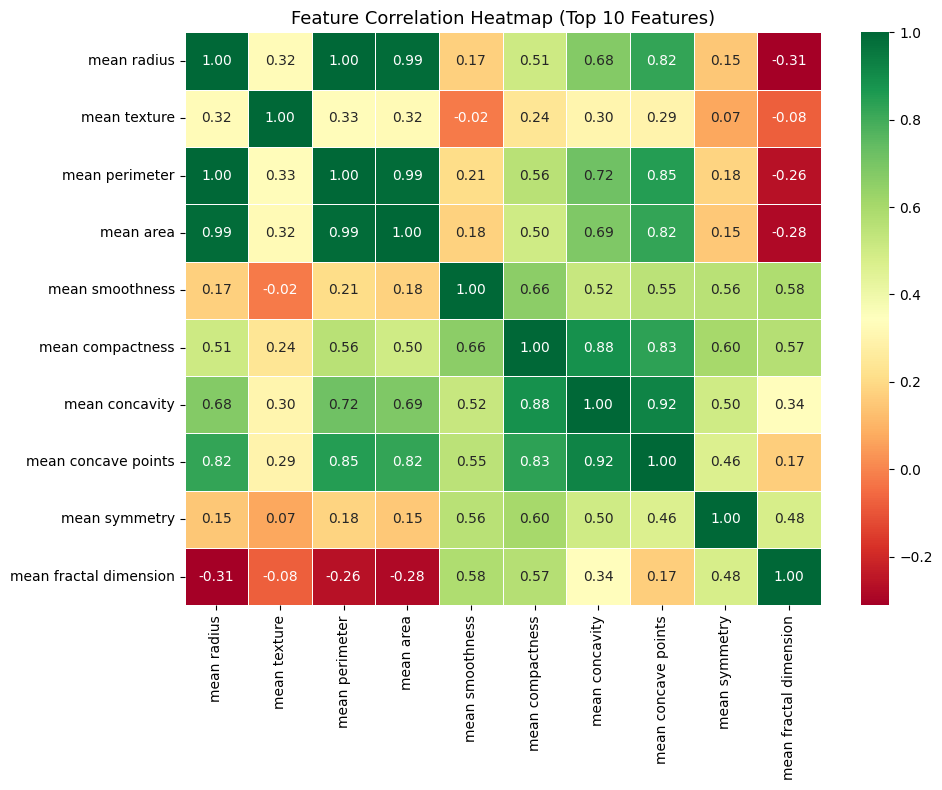

Chart saved!


In [ ]:
plt.figure(figsize=(10, 8))
# Use only first 10 features to keep it readable
top_features = df.columns[:10].tolist()
corr = df[top_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Top 10 Features)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("Chart saved!")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

# Prepare data
X = df.drop('diagnosis', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['diagnosis'])  # malignant=0, benign=1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"✅ Model Accuracy: {acc:.2%}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

✅ Model Accuracy: 96.49%

📋 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.96      0.99      0.97        71
      Benign       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



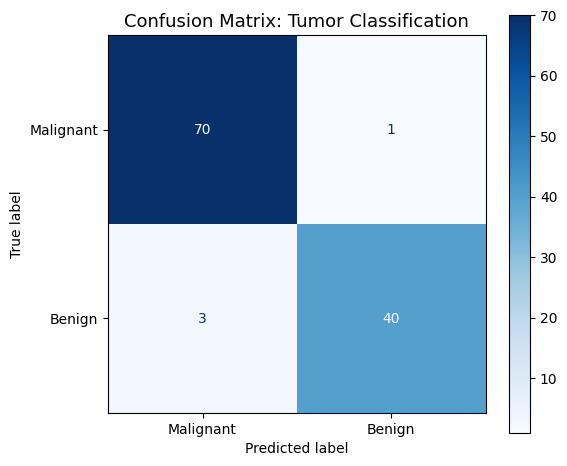

Chart saved!


In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['Malignant', 'Benign'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix: Tumor Classification', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Chart saved!")

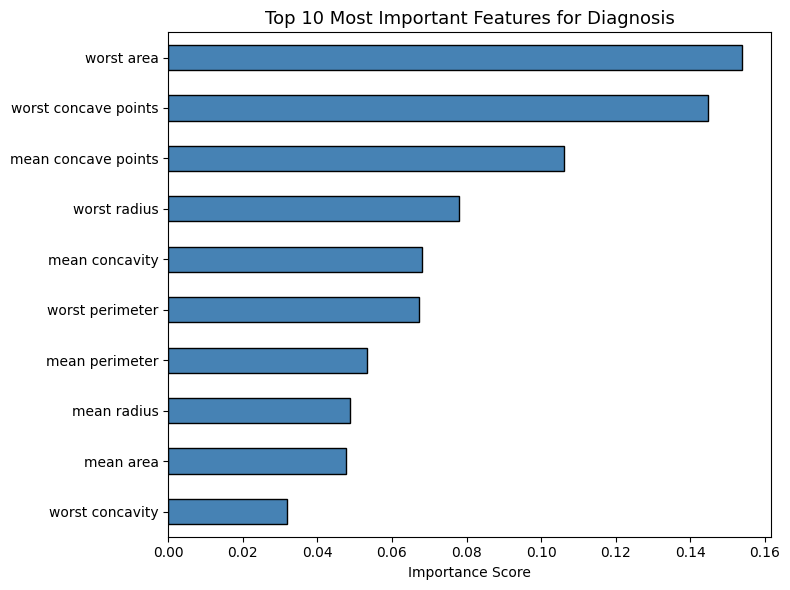

Chart saved!


In [ ]:
importances = pd.Series(
    model.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=True).tail(10)  # Top 10 features

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Most Important Features for Diagnosis', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Chart saved!")

In [ ]:
from google import genai
from google.colab import userdata

try:
    api_key = userdata.get('GOOGLE_API_KEY')
    client = genai.Client(api_key=api_key)

    report = classification_report(
        y_test, y_pred,
        target_names=['Malignant', 'Benign']
    )

    prompt = f"""
    You are a Senior Medical Research Data Analyst.

    A machine learning model was trained on the Wisconsin Breast Cancer Dataset
    to classify tumors as malignant (cancerous) or benign (non-cancerous)
    based on cell nucleus measurements.

    Model Results:
    - Model Used: Random Forest Classifier
    - Accuracy: {acc:.2%}
    - Classification Report:
    {report}

    The most important features were: mean radius, mean perimeter,
    mean concave points, and mean area.

    Please provide:
    1. A brief explanation of what this model does and why it matters in healthcare.
    2. A simple explanation of the accuracy and what the classification report means
       for malignant vs benign detection.
    3. What the most important features tell us medically about tumor detection.
    4. A disclaimer that this is an AI-assisted screening tool and all results
       must be reviewed and confirmed by a qualified medical professional.
    """

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    print("=" * 60)
    print("🤖 AI-Generated Healthcare Summary")
    print("=" * 60)
    print(response.text)

    # Save to file
    with open("ai_summary.txt", "w") as f:
        f.write(response.text)
    print("\n✅ Summary saved to ai_summary.txt")

except Exception as e:
    print(f"❌ Error: {e}")

🤖 AI-Generated Healthcare Summary
As a Senior Medical Research Data Analyst, I'm pleased to provide an analysis of the Random Forest Classifier model trained on the Wisconsin Breast Cancer Dataset.

---

### Analysis of Breast Tumor Classification Model

#### 1. What This Model Does and Why It Matters in Healthcare

This model is a **machine learning tool** designed to help classify breast tumors as either **malignant (cancerous)** or **benign (non-cancerous)**. It does this by analyzing various microscopic measurements taken from cell nuclei, such as their size, shape, and texture, which were fed into the model during its training phase.

**Why it matters in healthcare:**
*   **Assisted Diagnosis:** This model can act as a powerful *screening* or *support* tool for pathologists and oncologists. By quickly and accurately suggesting whether a tumor is likely malignant or benign, it can help streamline the diagnostic process.
*   **Consistency and Efficiency:** AI models can provide cons

In [22]:
from google.colab import files

# Download all saved files
files_to_download = [
    'diagnosis_distribution.png',
    'feature_comparison.png',
    'correlation_heatmap.png',
    'confusion_matrix.png',
    'feature_importance.png',
    'ai_summary.txt'
]

for file in files_to_download:
    files.download(file)

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
